In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (
    LogisticRegression, SGDClassifier
)
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, roc_auc_score
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [3]:
df_clf = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
df_clf.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Pre- Processing

In [4]:
df_clf.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df_clf.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df_clf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
# cleaning dataset
# irrelevant column: PassengerId, Name, Cabin (too much null value), ticket (unique irrelavent values)
df_clf = df_clf[['Survived','Pclass','Sex','Age','SibSp','Parch','Fare']]
df_clf['Age'] = df_clf['Age'].fillna(df_clf['Age'].mean())
df_clf['Sex'] = df_clf['Sex'].map({'male':0, 'female':1})

In [8]:
df_clf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 48.9 KB


In [9]:
df_clf.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,0,22.0,1,0,7.2500
1,1,1,1,38.0,1,0,71.2833
2,1,3,1,26.0,0,0,7.9250
3,1,1,1,35.0,1,0,53.1000
4,0,3,0,35.0,0,0,8.0500


In [10]:
df_clf['Pclass'].unique()

array([3, 1, 2])

In [11]:
df_clf['SibSp'].unique()

array([1, 0, 3, 4, 2, 5, 8])

In [12]:
df_clf['Parch'].unique()

array([0, 1, 2, 5, 3, 4, 6])

In [13]:
df_clf['Sex'].unique()

array([0, 1])

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
# train - test split
X_clf = df_clf.drop('Survived', axis=1)
y_clf = df_clf['Survived']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

num_cols = ['Age', 'Fare', 'Pclass', 'SibSp', 'Parch']

In [16]:

# 1. Scale the numerical columns directly in the dataframe
scaler = StandardScaler()

# Fit and transform the training set
X_train_c[num_cols] = scaler.fit_transform(X_train_c[num_cols])

# Only transform the test set (to avoid data leakage)
X_test_c[num_cols] = scaler.transform(X_test_c[num_cols])

# 2. Sex is already 0/1, so we do nothing to it!
# Your data is now ready.

In [17]:
# Classification Evaluation Function
def evaluate_classification(model):
    model.fit(X_train_c, y_train_c)
    y_pred = model.predict(X_test_c)
    
    print("Accuracy:", accuracy_score(y_test_c, y_pred))
    print("Precision:", precision_score(y_test_c, y_pred))
    print("Recall:", recall_score(y_test_c, y_pred))
    print("F1 Score:", f1_score(y_test_c, y_pred))
    
    print("\nConfusion Matrix:\n", confusion_matrix(y_test_c, y_pred))
    print("\nClassification Report:\n", classification_report(y_test_c, y_pred))
    print("-"*40)

# Logistic Regression (L2)

In [18]:
# Logistic Regression (L2)
log_reg_l2 = LogisticRegression(penalty='l2', solver='lbfgs')
evaluate_classification(log_reg_l2)

Accuracy: 0.8156424581005587
Precision: 0.8059701492537313
Recall: 0.7297297297297297
F1 Score: 0.7659574468085106

Confusion Matrix:
 [[92 13]
 [20 54]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.88      0.85       105
           1       0.81      0.73      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.81       179

----------------------------------------


# Logistic Regression (L1)

In [19]:
# Logistic Regression (L1)
log_reg_l1 = LogisticRegression(penalty='l1', solver='liblinear')
evaluate_classification(log_reg_l1)

Accuracy: 0.7988826815642458
Precision: 0.7794117647058824
Recall: 0.7162162162162162
F1 Score: 0.7464788732394366

Confusion Matrix:
 [[90 15]
 [21 53]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

----------------------------------------


# ElasticNet Logistic

In [20]:
# ElasticNet Logistic
log_reg_en = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5
)
evaluate_classification(log_reg_en)

Accuracy: 0.8044692737430168
Precision: 0.7910447761194029
Recall: 0.7162162162162162
F1 Score: 0.75177304964539

Confusion Matrix:
 [[91 14]
 [21 53]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.87      0.84       105
           1       0.79      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179

----------------------------------------


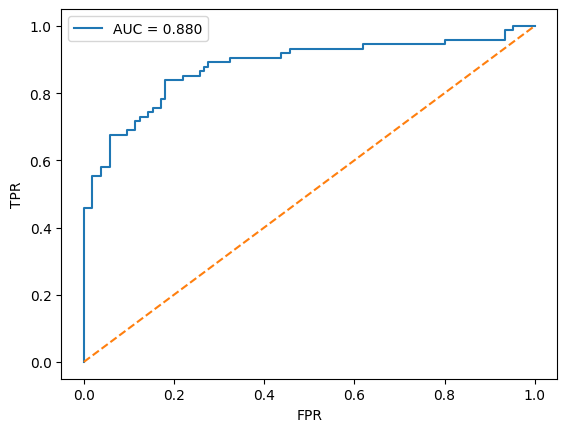

In [21]:
# ROC Curve
log_reg_l2.fit(X_train_c, y_train_c)
y_prob = log_reg_l2.predict_proba(X_test_c)[:,1]

fpr, tpr, _ = roc_curve(y_test_c, y_prob)
auc = roc_auc_score(y_test_c, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

# KNN

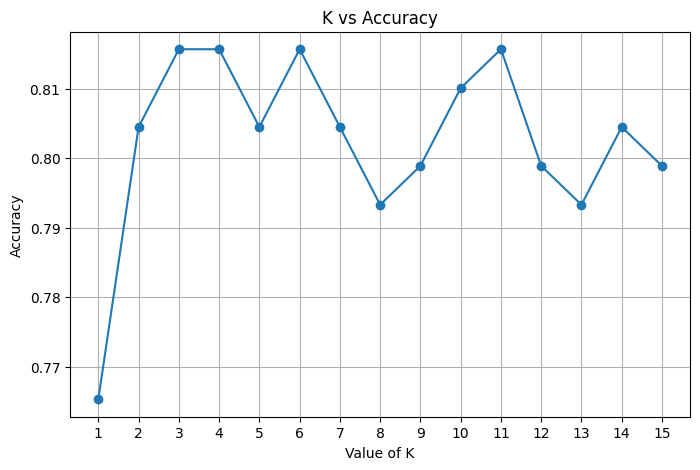

In [22]:
# KNN – Hyperparameter Tuning (k from 1 to 15)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

k_values = range(1, 16)
accuracy_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_c, y_train_c)
    y_pred = knn.predict(X_test_c)
    
    acc = accuracy_score(y_test_c, y_pred)
    accuracy_scores.append(acc)

# Plot graph
plt.figure(figsize=(8,5))
plt.plot(k_values, accuracy_scores, marker='o')
plt.xlabel("Value of K")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [23]:
# Select Best K
best_k = k_values[accuracy_scores.index(max(accuracy_scores))]
print("Best K:", best_k)
print("Best Accuracy:", max(accuracy_scores))

Best K: 3
Best Accuracy: 0.8156424581005587


In [24]:
# Train Final Model with Best K
final_knn = KNeighborsClassifier(n_neighbors=best_k)
evaluate_classification(final_knn)

Accuracy: 0.8156424581005587
Precision: 0.7808219178082192
Recall: 0.7702702702702703
F1 Score: 0.7755102040816326

Confusion Matrix:
 [[89 16]
 [17 57]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.85      0.84       105
           1       0.78      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

----------------------------------------


# Gaussian Naive Bayes

In [25]:
# Gaussian Naive Bayes
gnb = GaussianNB()
evaluate_classification(gnb)

Accuracy: 0.770949720670391
Precision: 0.726027397260274
Recall: 0.7162162162162162
F1 Score: 0.7210884353741497

Confusion Matrix:
 [[85 20]
 [21 53]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.81      0.81       105
           1       0.73      0.72      0.72        74

    accuracy                           0.77       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.77      0.77      0.77       179

----------------------------------------


# SGD Classifier

In [26]:
# SGD Classifier
sgd_clf = SGDClassifier(loss='log_loss', max_iter=1000)
evaluate_classification(sgd_clf)

Accuracy: 0.770949720670391
Precision: 0.7088607594936709
Recall: 0.7567567567567568
F1 Score: 0.7320261437908496

Confusion Matrix:
 [[82 23]
 [18 56]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.78      0.80       105
           1       0.71      0.76      0.73        74

    accuracy                           0.77       179
   macro avg       0.76      0.77      0.77       179
weighted avg       0.77      0.77      0.77       179

----------------------------------------


# SVM

In [27]:
from sklearn.svm import SVC

# Train SVM on full features
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
evaluate_classification(svm_clf)

Accuracy: 0.8100558659217877
Precision: 0.803030303030303
Recall: 0.7162162162162162
F1 Score: 0.7571428571428571

Confusion Matrix:
 [[92 13]
 [21 53]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

----------------------------------------


# Decision Tree

In [28]:
from sklearn.tree import DecisionTreeClassifier

# Initialize Decision Tree
# max_depth=5 helps prevent the tree from memorizing the training data (overfitting)
dt_clf = DecisionTreeClassifier(max_depth=5, random_state=42)

# Evaluate using your function
evaluate_classification(dt_clf)

Accuracy: 0.8044692737430168
Precision: 0.8305084745762712
Recall: 0.6621621621621622
F1 Score: 0.7368421052631579

Confusion Matrix:
 [[95 10]
 [25 49]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.90      0.84       105
           1       0.83      0.66      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.80      0.80       179

----------------------------------------


# Random Forest

In [29]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest
# n_estimators=100 is the number of trees in the forest
rf_clf = RandomForestClassifier(n_estimators=30, max_depth=7, random_state=42)

# Evaluate using your function
evaluate_classification(rf_clf)

Accuracy: 0.7932960893854749
Precision: 0.8135593220338984
Recall: 0.6486486486486487
F1 Score: 0.7218045112781954

Confusion Matrix:
 [[94 11]
 [26 48]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.90      0.84       105
           1       0.81      0.65      0.72        74

    accuracy                           0.79       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.79      0.79       179

----------------------------------------


# Random Forest without scaling

In [30]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

In [31]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest
# n_estimators=100 is the number of trees in the forest
rf_clf = RandomForestClassifier(n_estimators=30, max_depth=7, random_state=42)

# Evaluate using your function
evaluate_classification(rf_clf)

Accuracy: 0.7932960893854749
Precision: 0.8135593220338984
Recall: 0.6486486486486487
F1 Score: 0.7218045112781954

Confusion Matrix:
 [[94 11]
 [26 48]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.90      0.84       105
           1       0.81      0.65      0.72        74

    accuracy                           0.79       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.79      0.79       179

----------------------------------------
